## Ifylling av luckor med referensdata och blockerad korsvalidering
*E. Haaf (Chalmers), 2026*

Denna notebook fyller luckor i referensserier med hjälp av linjär regression genom att matcha varje referens-ID mot den SGU-serie som har hogst korrelation.

Steg:
1. Ladda in data
2. Visualisera data
3. Aggregera SGU-data till dagsmedel
4. Matcha varje referens-ID mot basta SGU-ID
5. Fyll luckor och berakna blockerad korsvalidering
6. Visualisera resultat
7. Spara resultat

### 0. Importera bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1. Ladda in data

In [2]:
# Sokvagar till data och resultat
sgu_path = "../data/sgu_data.csv"
ref_path = "../data/ref_gbg_long.csv"
filled_path = "../data/ref_gbg_long_filled_lm.csv"
metrics_path = "../data/cv_metrics_lm.csv"

# Konstanter
min_overlap = 30
start_date = pd.Timestamp("2018-01-01")

# Las SGU-data
sgu_raw = pd.read_csv(sgu_path, sep=";", na_values=["NA"])
sgu_raw["Date"] = pd.to_datetime(sgu_raw["Date"], errors="coerce")
sgu_raw["Value"] = pd.to_numeric(sgu_raw["Value"], errors="coerce")
sgu_raw = sgu_raw.dropna(subset=["Date"])

# Las referensdata
ref = pd.read_csv(ref_path, sep=";", na_values=["NA"])
ref["Date"] = pd.to_datetime(ref["Date"], errors="coerce")
ref["Value"] = (
    ref["Value"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .replace({"NA": np.nan, "nan": np.nan})
)
ref["Value"] = pd.to_numeric(ref["Value"], errors="coerce")
ref = ref.dropna(subset=["Date"])

print(f"SGU-data: {len(sgu_raw)} rader")
print(f"Referensdata: {len(ref)} rader")
print(f"Antal referens-ID: {ref['ID'].nunique()}")

SGU-data: 99688 rader
Referensdata: 18090 rader
Antal referens-ID: 9


### 2. Aggregera SGU-data till dagsmedel

In [3]:
sgu_daily = sgu_raw.assign(Date=sgu_raw["Date"].dt.date)
sgu_daily = sgu_daily.groupby(["ID", "Date"], as_index=False).agg(Value_d=("Value", "mean"))
sgu_daily["Date"] = pd.to_datetime(sgu_daily["Date"])
sgu_daily = sgu_daily[sgu_daily["Date"] > start_date].copy()

print(f"Aggregerad SGU-data: {len(sgu_daily)} rader")
print(f"Antal SGU-ID: {sgu_daily['ID'].nunique()}")

Aggregerad SGU-data: 14407 rader
Antal SGU-ID: 8


### 3. Visualisera data

### 3. Matcha varje referens-ID, fyll luckor och berakna blockerad korsvalidering

In [4]:
filled_parts = []
metrics_rows = []

for target_id, target_df in ref.groupby("ID"):
    target_df = target_df.sort_values("Date").copy()

    best_sgu_id = None
    best_corr = None
    best_overlap_count = 0

    target_obs = target_df.dropna(subset=["Value"])

    if not target_obs.empty:
        for sgu_id, sgu_df in sgu_daily.groupby("ID"):
            merged_match = target_obs.merge(sgu_df, on="Date", how="inner")
            merged_match = merged_match.dropna(subset=["Value", "Value_d"])

            if len(merged_match) < min_overlap:
                continue

            corr = merged_match["Value"].corr(merged_match["Value_d"])

            if pd.isna(corr):
                continue

            if best_corr is None or corr > best_corr:
                best_corr = corr
                best_sgu_id = sgu_id
                best_overlap_count = len(merged_match)

    if best_sgu_id is None:
        metrics_rows.append({
            "ID": target_id,
            "SGU_ID": np.nan,
            "overlap_count": 0,
            "filled_count": 0,
            "correlation": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
        })
        print(f"ID {target_id}: ingen giltig match")
        continue

    sgu_selected = sgu_daily[sgu_daily["ID"] == best_sgu_id].copy()
    merged = target_df.merge(sgu_selected, on="Date", how="left")

    train = merged.dropna(subset=["Value", "Value_d"])
    model = LinearRegression()
    model.fit(train[["Value_d"]], train["Value"])

    missing_mask = merged["Value"].isna() & merged["Value_d"].notna()
    merged["Value_filled"] = merged["Value"]

    if missing_mask.any():
        preds = model.predict(merged.loc[missing_mask, ["Value_d"]])
        merged.loc[missing_mask, "Value_filled"] = preds

    filled_count = int(missing_mask.sum())

    cv_data = merged.dropna(subset=["Value", "Value_d"]).sort_values("Date").copy()
    cv_data["fold"] = cv_data["Date"].dt.to_period("2M")

    y_true_all = []
    y_pred_all = []

    for fold, test in cv_data.groupby("fold"):
        train_fold = cv_data[cv_data["fold"] != fold]

        if train_fold.empty or test.empty:
            continue

        model_cv = LinearRegression()
        model_cv.fit(train_fold[["Value_d"]], train_fold["Value"])
        preds_cv = model_cv.predict(test[["Value_d"]])

        y_true_all.append(test["Value"].to_numpy())
        y_pred_all.append(preds_cv)

    if y_true_all:
        y_true = np.concatenate(y_true_all)
        y_pred = np.concatenate(y_pred_all)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
    else:
        mae = np.nan
        rmse = np.nan
        r2 = np.nan

    filled_parts.append(
        merged.assign(
            ID=target_id,
            SGU_ID=best_sgu_id,
            Value_raw=merged["Value"],
            Value=merged["Value_filled"],
        )
    )

    metrics_rows.append({
        "ID": target_id,
        "SGU_ID": best_sgu_id,
        "overlap_count": best_overlap_count,
        "filled_count": filled_count,
        "correlation": best_corr,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
    })

    print(f"ID {target_id}: SGU {best_sgu_id}, fyllda varden {filled_count}, R2={r2:.3f}")

print(f"\nBearbetade referens-ID: {ref['ID'].nunique()}")

ID obj_06: SGU 179_2, fyllda varden 1187, R2=0.506
ID obj_07: SGU 52_2, fyllda varden 1810, R2=0.791
ID obj_2U: SGU 179_2, fyllda varden 1147, R2=0.770
ID obj_30: SGU 52_2, fyllda varden 1785, R2=0.435
ID obj_3O: SGU 52_13, fyllda varden 1140, R2=0.608
ID obj_5B: SGU 52_14, fyllda varden 1130, R2=0.666
ID obj_5U: SGU 52_13, fyllda varden 950, R2=0.560
ID obj_8O: SGU 52_13, fyllda varden 1147, R2=0.574
ID obj_9O: SGU 52_9, fyllda varden 1132, R2=0.484

Bearbetade referens-ID: 9


### 4. Spara och visa resultat

In [5]:
if filled_parts:
    filled_all = pd.concat(filled_parts, ignore_index=True)
    filled_all = filled_all.sort_values(["ID", "Date"])
    filled_export = filled_all[["Date", "ID", "Value", "Value_raw", "SGU_ID"]]
    filled_export.to_csv(filled_path, sep=";", index=False)
    print(f"Sparad fylld serie: {filled_path}")
else:
    filled_all = pd.DataFrame()

metrics_df = pd.DataFrame(metrics_rows).sort_values("ID")
metrics_df.to_csv(metrics_path, sep=";", index=False)
print(f"Sparade metriker: {metrics_path}")

pd.options.display.float_format = "{:,.4f}".format
display(metrics_df[["ID", "SGU_ID", "correlation", "filled_count", "r2"]].head(20))

Sparad fylld serie: ../data/ref_gbg_long_filled.csv
Sparade metriker: ../data/cv_metrics.csv


,ID,SGU_ID,correlation,filled_count,r2
0,obj_06,179_2,0.7593,1187,0.5055
1,obj_07,52_2,0.8953,1810,0.7905
2,obj_2U,179_2,0.8876,1147,0.7697
3,obj_30,52_2,0.6943,1785,0.4352
4,obj_3O,52_13,0.8110,1140,0.6084
5,obj_5B,52_14,0.8483,1130,0.6657
6,obj_5U,52_13,0.7691,950,0.5600
7,obj_8O,52_13,0.7816,1147,0.5742
8,obj_9O,52_9,0.7613,1132,0.4841


### 5. Enkel visualisering

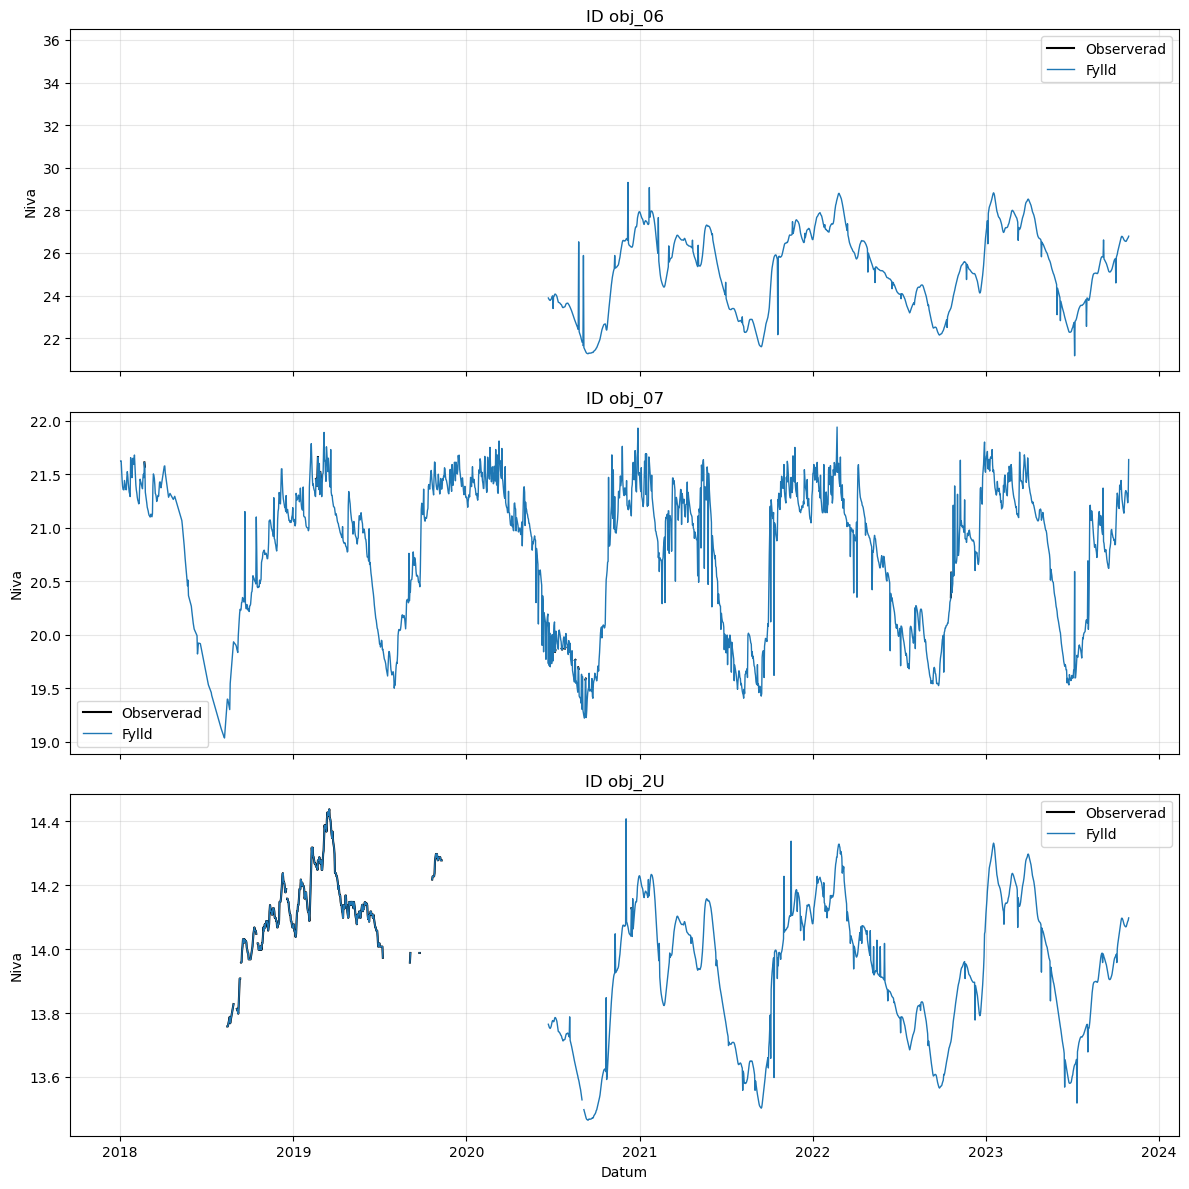

In [6]:
if not filled_all.empty:
    ids_to_plot = filled_all["ID"].drop_duplicates().head(3).tolist()

    fig, axes = plt.subplots(len(ids_to_plot), 1, figsize=(12, 4 * len(ids_to_plot)), sharex=True)

    if len(ids_to_plot) == 1:
        axes = [axes]

    for ax, target_id in zip(axes, ids_to_plot):
        part = filled_all[filled_all["ID"] == target_id].sort_values("Date")
        ax.plot(part["Date"], part["Value_raw"], color="black", linewidth=1.5, label="Observerad")
        ax.plot(part["Date"], part["Value"], color="tab:blue", linewidth=1.0, label="Fylld")
        ax.set_title(f"ID {target_id}")
        ax.set_ylabel("Niva")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[-1].set_xlabel("Datum")
    plt.tight_layout()
    plt.show()
else:
    print("Ingen serie att plotta.")